# import libraries

In [ ]:
import os
import time
from pathlib import Path

import pandas as pd  
import time 
from tqdm import tqdm 
from dotenv import load_dotenv, find_dotenv


# Directories

In [ ]:
DATA_DIR = Path("../data")
LATEST_MOVIES_PATH = DATA_DIR / 'latest_movies' / "latest_movies_fully_translated.csv"
TMDB_DIR = DATA_DIR / 'tmdb'
MOVIELENS_DIR = DATA_DIR / 'movielens'
print(f"DATA_DIR: {DATA_DIR.resolve()}")


# Các hàm util thống kê và vẽ biểu đồ

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_count_by_range(
    df_has_overview_vi,  # nhận vào df chưa overview_vi, từ đếm từ
    bins=None,
    title="Phân phối số từ theo khoảng",
    x_label="Khoảng số từ",
    y_label="Số lượng phim",
    figsize=(10, 6),
):
    if bins is None:
        bins = [0, 10, 20, 30, 50, 100, float("inf")]
    df_has_overview_vi['overview_vi_word_count'] = df_has_overview_vi['overview_vi'].fillna("").str.split().str.len()

    series = df_has_overview_vi['overview_vi_word_count']
    values = pd.to_numeric(series, errors="coerce").dropna()

    ranges = pd.cut(
        values,
        bins=bins,
        include_lowest=True,
        right=False,
    )

    distribution = ranges.value_counts().sort_index()

    ax = distribution.plot(
        kind="bar",
        figsize=figsize,
        color="steelblue",
        edgecolor="black",
    )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=45)

    for index, value in enumerate(distribution):
        ax.text(
            index,
            value,
            str(value),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    return distribution


# Load data

## MovieLens dataset

In [ ]:
movielens_df = {
    "ratings": pd.read_csv(MOVIELENS_DIR / "ratings.csv"),
    "tags": pd.read_csv(MOVIELENS_DIR / "tags.csv"),
    "links": pd.read_csv(MOVIELENS_DIR / "links.csv"),
    "movies": pd.read_csv(MOVIELENS_DIR / "movies.csv"),
    "genome_scores": pd.read_csv(MOVIELENS_DIR / "genome_scores.csv"),
    "genome_tags": pd.read_csv(MOVIELENS_DIR / "genome_tags.csv")
}

print('Số phim: ', movielens_df['movies'].shape[0]) 
print('Số người dùng: ', movielens_df['ratings']['userId'].nunique())
print('Số lượt đánh giá: ', movielens_df['ratings'].shape[0])


In [ ]:

display(movielens_df['movies'].head(5))
display(movielens_df['ratings'].head(5))
# display(movielens_df['tags'].head(5))
display(movielens_df['links'].head(5))
# display(movielens_df['genome_scores'].head(5))
# display(movielens_df['genome_tags'].head(5))

## TMDB movies info

In [ ]:
# tmdb_df1 = pd.read_csv(TMDB_DIR / 'movies_metadata_0-10000_1995-01-01.csv')
# tmdb_df2 = pd.read_csv(TMDB_DIR / 'movies_metadata_11000-20000_1995-01-01.csv')

# # merge
# tmdb_df = pd.concat([tmdb_df1, tmdb_df2], ignore_index=True)
# tmdb_df.to_csv(TMDB_DIR / 'movies_metadata_merged.csv', index=False, encoding='utf-8-sig')

# tmdb_df = pd.read_csv(TMDB_DIR / 'movies_metadata_merged_2000-01-01.csv', encoding='utf-8-sig')
# # tmdb_df2 = pd.read_csv(TMDB_DIR / 'movies_vietnamese_metadata_min-10-rating_1990_fully_translated.csv', encoding='utf-8-sig')
# tmdb_df = pd.concat([tmdb_df, tmdb_df2], ignore_index=True)
# tmdb_df.to_csv(TMDB_DIR / 'movies_data_fully_translated.csv', index=False, encoding='utf-8-sig')

# Đọc data 
tmdb_df = pd.read_csv(TMDB_DIR / 'movies_data_fully_translated.csv', encoding='utf-8-sig')

# Loại trùng
tmdb_df = tmdb_df.drop_duplicates(subset=['id'], keep='first')

# Fill NaN cho overview_vi và overview
tmdb_df['overview_vi'] = tmdb_df['overview_vi'].fillna('')
tmdb_df['overview'] = tmdb_df['overview'].fillna('')
# Nếu overview trống thì gán overview_vi = overview
tmdb_df.loc[tmdb_df['overview'].str.strip() == '', 'overview_vi'] = tmdb_df['overview']


# Thông tin cơ bản về data
print("Thông tin cơ bản về data:")
display(tmdb_df.count())
display(tmdb_df.info())
display(tmdb_df.head(5))

# Phân phối số từ của overview_vi
word_count_distribution = plot_count_by_range(
    tmdb_df,
    bins=[0, 10, 20, 30, 50, 100, 200, float("inf")],
    title="Phân phối số từ trong overview_vi",
)

# hiển thị head theo số từ
display(tmdb_df.sort_values('overview_vi', key=lambda x: x.str.len()).head(1000))

# Loại những dòng có overview trống hoặc overview_vi < 10 từ
short_movies_df = tmdb_df[(tmdb_df['overview_vi'].str.split().str.len() < 10) | (tmdb_df['overview'].str.strip() == '')] # overview = ''
display(short_movies_df.count())

## Latest TMDB movies 

In [ ]:
latest_movies_df = pd.read_csv(LATEST_MOVIES_PATH)

display(latest_movies_df.info())

display(latest_movies_df.count())

# Loại trùng
latest_movies_df = latest_movies_df.drop_duplicates(subset=['id'], keep='first')

# fill NaN cho overview_vi và overview
latest_movies_df['overview_vi'] = latest_movies_df['overview_vi'].fillna('')
latest_movies_df['overview'] = latest_movies_df['overview'].fillna('')
# Nếu overview trống thì gán overview_vi = overview
latest_movies_df.loc[latest_movies_df['overview'].str.strip() == '', 'overview_vi'] = latest_movies_df['overview']

# Vẽ phân phối số từ của overview_vi trong latest_movies_df
plot_count_by_range(
    latest_movies_df,
    bins=[0, 5, 10, 20, 30, 50, 100, 200, float("inf")],
    title="Phân phối số từ trong overview_vi của latest_movies_df",
)

# Hiện thị head: theo số từ trong overview_vi, từ ít đến nhiều
display(latest_movies_df.sort_values('overview_vi', key=lambda x: x.str.len()).head(1000))
display(latest_movies_df.sort_values('release_date', ascending=True).head(1000))


# Loại những dòng có overview trống hoặc overview_vi < 10 từ
short_movies_df = latest_movies_df[(latest_movies_df['overview_vi'].str.split().str.len() < 10) | (latest_movies_df['overview'].str.strip() == '')] # overview = ''
display(short_movies_df.count())

# Merge datasets: movielens (tmdb) + latest tmdb

In [39]:
all_movies_df = pd.concat([tmdb_df, latest_movies_df], ignore_index=True)

# Loại trùng
all_movies_df = all_movies_df.drop_duplicates(subset=['id'], keep='first')

all_movies_df = all_movies_df.rename(
    columns={
        "tmdbId": "tmdb_id",
    }
)

# xóa cột id
all_movies_df = all_movies_df.drop(columns=['id'], errors='ignore')

all_movies_df = all_movies_df.drop_duplicates(
    subset=["tmdb_id"],
    keep="first",
)

# Số phim không có movieId là latest_movies_df
print("Số phim không có movieId là latest_movies_df: ", all_movies_df[all_movies_df['movieId'].isnull()].shape[0])

print("Thông tin cơ bản về all_movies_df:")
display(all_movies_df.count())
display(all_movies_df.info())
display(all_movies_df.head(5))


Số phim không có movieId là latest_movies_df:  4891
Thông tin cơ bản về all_movies_df:


tmdb_id                   19706
title_vi                  19706
overview_vi               19706
genres                    19706
release_date              19700
poster_path               18983
adult                     19706
backdrop_path             17093
belongs_to_collection      2371
budget                    19706
homepage                     10
imdb_id                   16951
origin_country            19706
original_language         19706
original_title            19706
overview                  19706
popularity                19706
production_companies      19706
production_countries      19706
revenue                   19706
runtime                   19706
softcore                  19706
spoken_languages          19706
status                    19706
tagline                     675
title                     19706
video                     19706
vote_average              19706
vote_count                19706
movieId                   14815
is_ai_translated          19706
overview

<class 'pandas.DataFrame'>
Index: 19706 entries, 0 to 19747
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tmdb_id                 19706 non-null  float64
 1   title_vi                19706 non-null  str    
 2   overview_vi             19706 non-null  str    
 3   genres                  19706 non-null  str    
 4   release_date            19700 non-null  str    
 5   poster_path             18983 non-null  str    
 6   adult                   19706 non-null  bool   
 7   backdrop_path           17093 non-null  str    
 8   belongs_to_collection   2371 non-null   str    
 9   budget                  19706 non-null  int64  
 10  homepage                10 non-null     str    
 11  imdb_id                 16951 non-null  str    
 12  origin_country          19706 non-null  str    
 13  original_language       19706 non-null  str    
 14  original_title          19706 non-null  str    
 15  o

None

,tmdb_id,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
0,131232.0,Due amici,"Bạn bè hai tuổi, Nunzio và Pino, có chung một ...","[{'id': 18, 'name': 'Phim Chính Kịch'}]",2002-03-20,/ja7a0XvTUIQ6w1YdvbtytdC1lTF.jpg,False,/r1boovecPQAZo6vQBLZ4NVeRT2g.jpg,NaN,0,...,"[{'english_name': 'Italian', 'iso_639_1': 'it'...",Released,NaN,Due amici,False,5.400,7,723.0,True,126
1,79782.0,Wenecja,Một câu chuyện sắp tới kể về một cậu bé tên là...,"[{'id': 18, 'name': 'Phim Chính Kịch'}, {'id':...",2010-06-11,/jk8PwaZ14Duxy8hmLbYLFcYTUP9.jpg,False,/8vrmhLhPucmEOJr6EDxhxzVDMXi.jpg,NaN,1783810,...,"[{'english_name': 'Czech', 'iso_639_1': 'cs', ...",Released,NaN,Wenecja,False,7.139,18,895.0,True,34
2,141210.0,The Sleepover,"Thị trấn Derry có một bí mật, nhưng không ai n...","[{'id': 35, 'name': 'Phim Hài'}, {'id': 27, 'n...",2012-10-12,/tdaZD1Db9CXu96oLdAHElJsBPfb.jpg,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Sleepover,False,6.500,11,1115.0,True,20
3,143750.0,The Farmer's Wife,Khi môi trường của cô bị xâm chiếm bởi người n...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2012-06-20,NaN,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Farmer's Wife,False,10.000,1,2223.0,True,87
4,84198.0,A Place at the Table,"Sử dụng những câu chuyện cá nhân, những tài li...","[{'id': 99, 'name': 'Phim Tài Liệu'}]",2012-03-22,/ptli8HtDrapZdVdBnYSN8zxJtw0.jpg,False,/hdFefzO4RPq4txKEbFU7EulePsS.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,A Place at the Table,False,6.593,27,2679.0,True,65


In [ ]:
import ast


def parse_genres(value):
    """Parse genres stored as Python-list strings into a list of dictionaries."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    if not isinstance(value, str) or not value.strip():
        return []

    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

    return parsed if isinstance(parsed, list) else []


# Keep the full merged catalog, including latest TMDB movies without MovieLens movieId.
all_movies_df = all_movies_df.copy()
all_movies_df['movieId'] = pd.to_numeric(all_movies_df['movieId'], errors='coerce').astype('Int64')
# all_movies_df['tmdb_id'] = pd.to_numeric(
#     all_movies_df['tmdb_id'].fillna(all_movies_df.get('id')),
#     errors='coerce',
# ).astype('Int64')

valid_movie_ids = set(all_movies_df['tmdb_id'].dropna().astype('int64'))
ratings_df = movielens_df['ratings'].copy()
ratings_before = len(ratings_df)
ratings_df['movieId'] = pd.to_numeric(ratings_df['movieId'], errors='coerce').astype('Int64')
ratings_df = ratings_df[ratings_df['movieId'].isin(valid_movie_ids)].reset_index(drop=True)

print(f'Ratings trước lọc: {ratings_before:,}')
print(f'Ratings sau lọc movieId: {len(ratings_df):,}')
print(f'MovieId hợp lệ: {len(valid_movie_ids):,}')
print(f'User còn tương tác hợp lệ: {ratings_df["userId"].nunique():,}')

assert ratings_df['movieId'].notna().all()
assert set(ratings_df['movieId'].astype('int64')).issubset(valid_movie_ids)

parsed_genres = all_movies_df[['tmdb_id', 'genres']].copy()
parsed_genres['genres'] = parsed_genres['genres'].map(parse_genres)
parsed_genres = parsed_genres.explode('genres').dropna(subset=['genres'])
parsed_genres['genre_id'] = parsed_genres['genres'].map(
    lambda genre: genre.get('id') if isinstance(genre, dict) else None
)
parsed_genres['genre_name'] = parsed_genres['genres'].map(
    lambda genre: genre.get('name') if isinstance(genre, dict) else None
)

movie_genres_df = (
    parsed_genres[['tmdb_id', 'genre_id', 'genre_name']]
    .dropna(subset=['tmdb_id', 'genre_id', 'genre_name'])
    .assign(
        tmdb_id=lambda frame: pd.to_numeric(frame['tmdb_id'], errors='coerce').astype('Int64'),
        genre_id=lambda frame: pd.to_numeric(frame['genre_id'], errors='coerce').astype('Int64'),
    )
    .drop_duplicates(['tmdb_id', 'genre_id'])
    .reset_index(drop=True)
)

genres_df = (
    movie_genres_df[['genre_id', 'genre_name']]
    .rename(columns={'genre_name': 'name'})
    .drop_duplicates(['genre_id', 'name'])
    .sort_values(['genre_id', 'name'])
    .reset_index(drop=True)
)

print(f'Movie-genre relationships: {len(movie_genres_df):,}')
print(f'Unique genres: {len(genres_df):,}')
display(genres_df)
display(movie_genres_df.head())

print('Movie columns: ', all_movies_df.columns)

ratings_df.to_csv(MOVIELENS_DIR / 'ratings_filtered_by_movie.csv', index=False)
movie_genres_df.to_csv(TMDB_DIR / 'movie_genres.csv', index=False, encoding='utf-8-sig')
genres_df.to_csv(TMDB_DIR / 'genres.csv', index=False, encoding='utf-8-sig')

Ratings trước lọc: 27,753,444
Ratings sau lọc movieId: 5,617,578
MovieId hợp lệ: 19,706
User còn tương tác hợp lệ: 267,389
Movie-genre relationships: 41,744
Unique genres: 19


,genre_id,name
0,12,Phim Phiêu Lưu
1,14,Phim Giả Tượng
2,16,Phim Hoạt Hình
3,18,Phim Chính Kịch
4,27,Phim Kinh Dị
5,28,Phim Hành Động
6,35,Phim Hài
7,36,Phim Lịch Sử
8,37,Phim Miền Tây
9,53,Phim Gây Cấn


,tmdb_id,genre_id,genre_name
0,131232,18,Phim Chính Kịch
1,79782,18,Phim Chính Kịch
2,79782,10749,Phim Lãng Mạn
3,141210,35,Phim Hài
4,141210,27,Phim Kinh Dị


Movie columns:  Index(['tmdb_id', 'title_vi', 'overview_vi', 'genres', 'release_date',
       'poster_path', 'adult', 'backdrop_path', 'belongs_to_collection',
       'budget', 'homepage', 'imdb_id', 'origin_country', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'revenue', 'runtime', 'softcore',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'movieId', 'is_ai_translated',
       'overview_vi_word_count'],
      dtype='str')


Phân phối số từ trong overview_vi của all_movies_df:


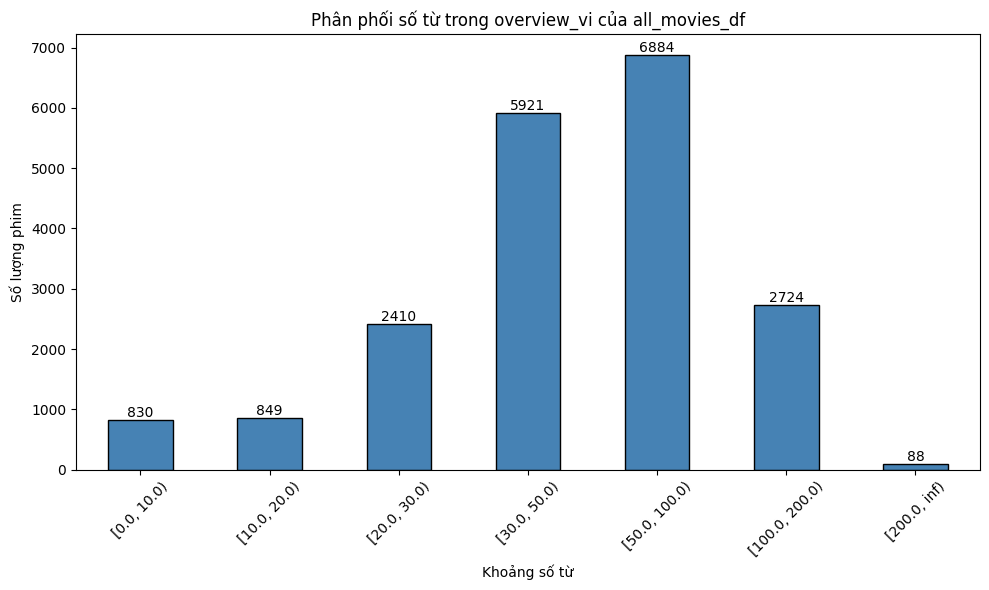

Hiển thị theo ngày release_date, từ cũ đến mới:


,tmdb_id,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
12328,88953.0,Ucho,Chính phủ Lud trở thành nghi phạm sau khi nhiề...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 18...",1990-01-01,/9cQyM8b7WpXU894VP3iJrnVDR27.jpg,False,/bjuttI5ewihYXhODlYXv82iKU1A.jpg,NaN,0,...,"[{'english_name': 'Czech', 'iso_639_1': 'cs', ...",Released,NaN,Ucho,False,7.247,73,42176,True,61
12708,30647.0,12:01 PM,12 giờ sáng là một bộ phim ngắn năm 1990 của J...,"[{'id': 878, 'name': 'Phim Khoa Học Viễn Tưởng'}]",1990-01-01,/zT5R8VahhZlE1TDcwEtmvyr8c8K.jpg,False,/eWFz1KIhWk4TOC4BCBRrAHNnP1d.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,12:01 PM,False,6.968,47,128844,True,24
11132,25018.0,Leatherface: The Texas Chainsaw Massacre III,Hai sinh viên đại học lái xe đến bờ biển bị dụ...,"[{'id': 27, 'name': 'Phim Kinh Dị'}, {'id': 53...",1990-01-12,/4Vhv0vRqirhvbudRcNctFgxoFtI.jpg,False,/1XVfmGPQslh25GMJeaggGtYPc9E.jpg,"{'id': 111751, 'name': 'Loạt phim Tử Thần Vùng...",2000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Leatherface: The Texas Chainsaw Massacre III,False,5.425,667,2461,True,40
11974,11060.0,Internal Affairs,Anh ta và cộng sự của Amy Wallace sẽ sớm xem x...,"[{'id': 80, 'name': 'Phim Hình Sự'}, {'id': 18...",1990-01-12,/A4pH8DiNFEf2AgXkM4zk3ZpblV.jpg,False,/a7RMVypNmxvEG0SzG9kXBJivfxX.jpg,NaN,15000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Internal Affairs,False,6.371,463,7791,True,27
12082,60778.0,Downtown,Sĩ quan Alex Kearney tuần tra một khu phố lớn ...,"[{'id': 28, 'name': 'Phim Hành Động'}, {'id': ...",1990-01-12,/mNZxZ9VcpNBTipjaKyZqEvvsKjB.jpg,False,/n23dBKQHqy7dlWVhW4Oc96xaGNa.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Downtown,False,5.696,46,26682,True,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12474,81895.0,MacGyver: Lost Treasure of Atlantis,Ông MacGyver và cụ của ông cuối cùng đã tìm ki...,"[{'id': 28, 'name': 'Phim Hành Động'}, {'id': ...",1994-05-14,/hcmocdC6Rp0w6C8M4i1yvewmgNL.jpg,False,/fjrLJZ18NfSPkByHeiGUqKw1TP1.jpg,"{'id': 209739, 'name': 'MacGyver Collection', ...",0,...,"[{'english_name': 'French', 'iso_639_1': 'fr',...",Released,NaN,MacGyver: Lost Treasure of Atlantis,False,6.300,64,73499,True,15
12065,124029.0,A Million to Juan,"Một ngày nọ, một ngày nọ, một người đàn ông cũ...","[{'id': 35, 'name': 'Phim Hài'}]",1994-05-15,/nA8ehfPUxzD6N7YgoWfR1PSYVlF.jpg,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,A Million to Juan,False,5.375,8,8843,True,63
12165,19223.0,Una pura formalità,Thanh tra đang nghi ngờ khi Onoff được đưa vào...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 53...",1994-05-15,/lDc5hmjfB5u4lHgo3rS4rKNYW54.jpg,False,/88FnsK3iF9rWdR36N3anp1oYVYJ.jpg,NaN,0,...,"[{'english_name': 'French', 'iso_639_1': 'fr',...",Released,NaN,Una pura formalità,False,7.403,402,26875,True,53
10559,64567.0,Grosse Fatigue,"Sự căng thẳng và quá mệt mỏi, ngôi sao điện ản...","[{'id': 35, 'name': 'Phim Hài'}]",1994-05-18,/aTe0UsF2dFW1TzpPI2R10ViW8m2.jpg,False,/4DgcfG8h13gGZQyUW7I4rWiU32I.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Grosse Fatigue,False,6.000,125,1174,True,75


Hiển thị theo số từ trong overview_vi, từ ít đến nhiều:


,tmdb_id,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
19699,1769437.0,Crisálida,,[],2026-09-03,/JqVOJ60AL9JzPQI6rbkcY9gv1b.jpg,False,/6V7GYUJPSJ0HmYhICiPR3bKsVaH.jpg,NaN,0,...,"[{'english_name': 'Portuguese', 'iso_639_1': '...",Released,NaN,Crisálida,False,0.000,0,<NA>,True,0
19576,1767161.0,Μούσκεμα,,"[{'id': 16, 'name': 'Phim Hoạt Hình'}, {'id': ...",2026-09-06,/f8jX24mqvVc7J6PeUsfusu8D9mx.jpg,False,/q032qBCbP0UvqYNZHmE7ZiZXqp5.jpg,NaN,0,...,[],Released,NaN,Μούσκεμα,False,0.000,0,<NA>,True,0
19568,1766996.0,Cinema Rialto,,"[{'id': 16, 'name': 'Phim Hoạt Hình'}, {'id': ...",2026-09-06,/alDgnmDcL97TNdbo3bMuFno4CEj.jpg,False,/o9VR7jxPZf1fqtiX6y2BTfj1hih.jpg,NaN,0,...,[],Released,NaN,Cinema Rialto,False,0.000,0,<NA>,True,0
17920,1757657.0,덕창,,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2026-09-04,NaN,False,NaN,NaN,0,...,[],Released,NaN,덕창,False,0.000,0,<NA>,True,0
17927,1755122.0,N E U R I L L A N,,[],2026-08-19,/1qytrTnwzAI0hXCPya6AcSXEQWJ.jpg,False,/oP6v3Up1o6xvfN1CLO74ltvWSRY.jpg,NaN,0,...,[],Released,NaN,N E U R I L L A N,False,0.000,0,<NA>,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19193,1711881.0,Mamma Mia: Que inesperado!,♪ Hai người bên nhau gặp nhau và ♪ Một cuộc hẹ...,"[{'id': 99, 'name': 'Phim Tài Liệu'}]",2026-08-07,/h3t3zBbwYpMmIVR8PhAOFu2Kai0.jpg,False,/6dzBN3m4B3UJAPxs7mhWV3D2XX4.jpg,NaN,0,...,"[{'english_name': 'Spanish', 'iso_639_1': 'es'...",Released,NaN,Mamma Mia: Que inesperado!,False,0.000,0,<NA>,True,15
1109,55015.0,Home Room,Một tay súng trường trung học có mặt ở trường ...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2002-04-12,/37BPWVtB956pkDIZarmjR2GjKVs.jpg,False,/4cRIz8wkaH9BekOnRC9d8ki4xxV.jpg,NaN,0,...,"[{'english_name': 'Spanish', 'iso_639_1': 'es'...",Released,NaN,Home Room,False,6.800,42,6704,True,13
13636,353069.0,Ngày Của Mẹ,3 thế hệ tụ họp lại với nhau trong tuần trước ...,"[{'id': 35, 'name': 'Phim Hài'}, {'id': 18, 'n...",2016-04-28,/1TGkhTsbkm2v1nMGJW0eTOFBjAd.jpg,False,/3wRjFLgFbMcA05oIRD3jL58pBCm.jpg,NaN,25000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Ngày Của Mẹ,False,6.000,1323,157667,True,14
6631,143800.0,Pokłosie,Hai anh em đang cố gắng tìm ra sự thật từ nhiề...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 18...",2012-11-09,/nOvZaOA5d0rDx7hg3XaC2TLNeAF.jpg,False,/jmlATmv6IEIDfrX9vrxoT3epLa9.jpg,NaN,0,...,"[{'english_name': 'Polish', 'iso_639_1': 'pl',...",Released,NaN,Pokłosie,False,6.600,100,98485,True,14


Số lượng phim theo nguồn dữ liệu:


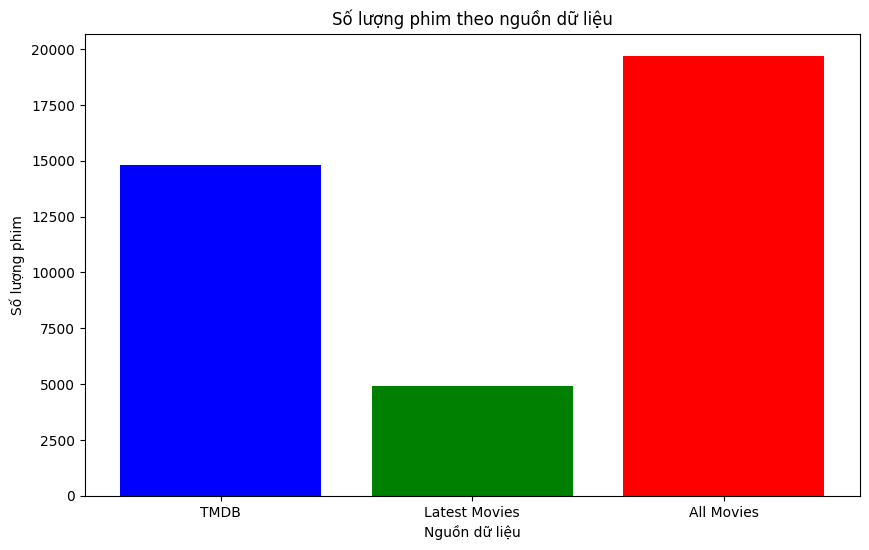

None

Phân phối số lượng phim theo năm (1990-2026):


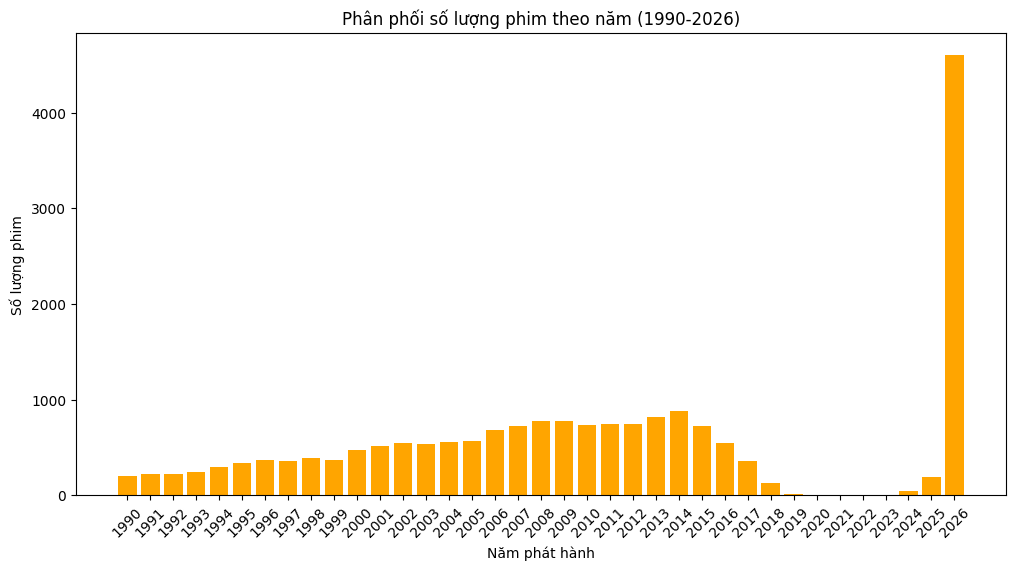

None

In [41]:

print("Phân phối số từ trong overview_vi của all_movies_df:")
plot_count_by_range(
    all_movies_df,
    bins=[0, 10, 20, 30, 50, 100, 200, float("inf")],
    title="Phân phối số từ trong overview_vi của all_movies_df",
)

# Luu all_movies_df ra file CSV
all_movies_df.to_csv(TMDB_DIR / 'all_movies_fully_translated.csv', index=False, encoding='utf-8-sig')

# Hiển thị theo ngày release_date, từ cũ đến mới
print("Hiển thị theo ngày release_date, từ cũ đến mới:")
display(all_movies_df.sort_values('release_date', ascending=True).head(1000))

# Hiển thị theo số từ trong overview_vi, từ ít đến nhiều
print("Hiển thị theo số từ trong overview_vi, từ ít đến nhiều:")
display(all_movies_df.sort_values('overview_vi', key=lambda x: x.str.len()).head(1000))


# Số lượng phim: biểu đồ cột, color khác nhau
def plot_movie_count_by_source(tmdb_df, latest_movies_df, all_movies_df):
    plt.figure(figsize=(10, 6))
    colors = ['blue', 'green', 'red']
    movie_counts = [tmdb_df.shape[0], latest_movies_df.shape[0], all_movies_df.shape[0]]
    sources = ['TMDB', 'Latest Movies', 'All Movies']
    plt.bar(sources, movie_counts, color=colors)
    plt.title('Số lượng phim theo nguồn dữ liệu')
    plt.xlabel('Nguồn dữ liệu')
    plt.ylabel('Số lượng phim')
    plt.show()
print("Số lượng phim theo nguồn dữ liệu:")
display(plot_movie_count_by_source(tmdb_df, latest_movies_df, all_movies_df))


# Phân phối theo năm từ 1990 đến 2026: chu kỳ 5 năm
def plot_movie_count_by_year(all_movies_df):
    plt.figure(figsize=(12, 6))
    all_movies_df['release_year'] = pd.to_datetime(all_movies_df['release_date'], errors='coerce').dt.year
    year_counts = all_movies_df[(all_movies_df['release_year'] >= 1990) & (all_movies_df['release_year'] <= 2026)]['release_year'].value_counts().sort_index()
    plt.bar(year_counts.index, year_counts.values, color='orange')
    plt.title('Phân phối số lượng phim theo năm (1990-2026)')
    plt.xlabel('Năm phát hành')
    plt.ylabel('Số lượng phim')
    plt.xticks(year_counts.index, rotation=45)
    plt.show()
print("Phân phối số lượng phim theo năm (1990-2026):")
display(plot_movie_count_by_year(all_movies_df))

## Lọc tương tác tồn tại

In [42]:
# tmdb_df
# movielens_df['ratings']

## Lấy danh sách thể loại phim từ all movies

In [43]:
# all_movies_df
# Định dạng genres: [{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 18, 'name': 'Phim Chính Kịch'}, {'id': 53, 'name': 'Phim Gây Cấn'}]

## Bảng thể loại phim: genres_df